# CS231n Backpropagation Review Tutorial With Google Colab

This tutorial has been revised by Favour Nerrise for the Spring 2026 edition of [cs231n](https://cs231n.stanford.edu/).

It runs Python3 by default. For compatibility with our assignments, we will use Python 3.11.13 to enforce the Python version by clicking `Runtime -> Change Runtime Type` and selecting `2025.07` You can check your Python version at the command line by running `python --version`.

### Imports and Plotting Functions

In [1]:
import itertools
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.inspection import DecisionBoundaryDisplay

# Fix seed for reproducibility
np.random.seed(231)
np.set_printoptions(precision=4)

In [2]:
def plot_decision_boundary(
    estimator,
    X,
    *,
    grid_resolution=100,
    eps=1.0,
    ax=None,
    **kwargs,
):
    """Generates a contour plot of the estimator's prediction thresholds."""
    x0, x1 = X[:,0],X[:,1]

    x0_min, x0_max = x0.min() - eps, x0.max() + eps
    x1_min, x1_max = x1.min() - eps, x1.max() + eps

    xx0, xx1 = np.meshgrid(
        np.linspace(x0_min, x0_max, grid_resolution),
        np.linspace(x1_min, x1_max, grid_resolution),
    )

    X_grid = np.c_[xx0.ravel(), xx1.ravel()]

    response = estimator.forward(X_grid)

    display = DecisionBoundaryDisplay(
        xx0=xx0,
        xx1=xx1,
        response=response.reshape(xx0.shape),
    )
    display.plot(plot_method="contourf", ax=ax, **kwargs)
    return display

def visualize_dataset(x, y, title="Visualization of dataset", ax=None):
    """Generates a scatter plot of the data."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    scatter = ax.scatter(*x.T, c=y, edgecolors='k', linewidths=0.5, s=15)
    ax.set_title(title)
    ax.legend(handles=scatter.legend_elements()[0], labels=[0,1])
    ax.grid(visible=True, which='both')
    plt.show()

def visualize_weights(mlp, gradients=True):
    """Visualize the first layer weights and gradients of an MLPClassifier."""
    fig, ax = plt.subplots(figsize=(5, 5))
    z = np.zeros(mlp.w1.shape)
    ax.quiver(z[0, :], z[1, :], mlp.w1[0, :], mlp.w1[1, :],
              scale=1, width=0.005, angles='xy', scale_units='xy',
              color='tab:blue', label='Weight vectors $\\mathbf{w}_i$')
    if gradients:
        ax.quiver(mlp.w1[0, :], mlp.w1[1, :],
                  -mlp.lr * mlp.grad_w1[0, :], -mlp.lr * mlp.grad_w1[1, :],
                  scale=1, width=0.01, angles='xy', scale_units='xy',
                  color='r', label='Gradient update $-\\alpha \\nabla_{\\mathbf{w}_i} \\ell$')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_title("First-layer weight vectors")
    ax.grid(visible=True, which='both')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    plt.show()

### Generate Example Dataset

We create a binary classification dataset of two concentric circles using `sklearn.datasets.make_circles`. The inner circle is class 1 and the outer circle is class 0. This is a classic example of a dataset that is **not linearly separable**, i.e., a single linear classifier cannot solve it, which motivates the need for a neural network with a hidden layer.

In [3]:
X, y = datasets.make_circles(n_samples=1000, noise=0.05, factor=0.5)
y = y[:, np.newaxis]
print(f"The data has dimensions {X.shape} and the labels have dimensions {y.shape}.")

The data has dimensions (1000, 2) and the labels have dimensions (1000, 1).


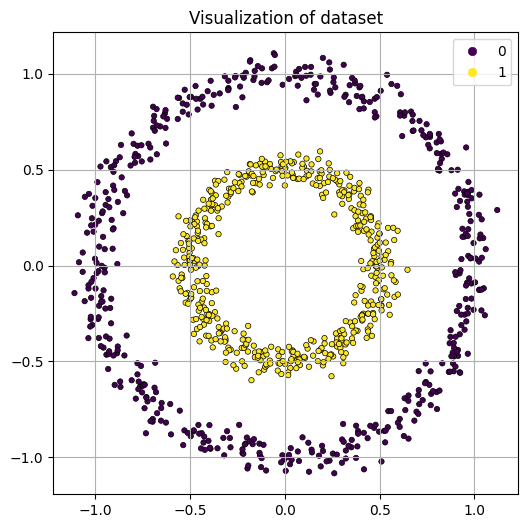

In [ ]:
visualize_dataset(X, y)

### Define Activation Functions and Classifier

We implement a simple two-layer MLP for binary classification. The network computes:

$$f_\theta(\mathbf{x}) = \sigma\!\Big(\underbrace{\max(0,\;\mathbf{x}\mathbf{w}_1)\,\mathbf{w}_2 + b}_{\mathbf{z}}\Big)$$

where $\mathbf{w}_1 \in \mathbb{R}^{2 \times 3}$, $\mathbf{w}_2 \in \mathbb{R}^{3 \times 1}$, and $b \in \mathbb{R}$.

The parameters $\theta = \{\mathbf{w}_1, \mathbf{w}_2, b\}$ are learned via gradient descent. We need the gradient $\nabla_\theta \ell$ of the binary cross-entropy loss, and **backpropagation** is how we compute it efficiently, by applying the chain rule one node at a time through the computational graph:

$$\mathbf{x} \;\xrightarrow{\times \mathbf{w}_1}\; \xrightarrow{\text{ReLU}}\; \mathbf{h} \;\xrightarrow{\times \mathbf{w}_2 + b}\; \mathbf{z} \;\xrightarrow{\sigma}\; \mathbf{y}_{\text{pred}} \;\xrightarrow{\text{BCE}}\; \ell$$

In [4]:
def relu(x):
    """Rectified linear activation function."""
    return np.maximum(x, 0)

def sigmoid(x):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-x))

def cross_entropy(preds, labels):
    """
    Binary cross entropy loss.

    Args:
        preds:  predicted probabiltiies
        labels: ground truth labels
    """
    return -np.mean(labels * np.log(preds) + (1 - labels) * np.log(1 - preds))

In [5]:
class MLPClassifier():
    def __init__(self, lr=1e-2, in_dim=2, out_dim=1, h_dim=3):
        """
        Defines the learning rate and initializes the weight matrices
        for a simple multilayer perceptron.

        Args:
            lr:      learning rate
            in_dim:  input dimension
            out_dim: output dimension
            h_dim:   hidden dimension
        """
        self.lr = lr

        # Randomly initialize weights from a Gaussian distribution
        self.w1 = np.random.randn(in_dim, h_dim) * np.sqrt(2 / in_dim)
        self.w2 = np.random.randn(h_dim, out_dim) * np.sqrt(2 / h_dim)
        self.b = np.zeros(out_dim) + 0.1

    def forward(self, x):
        """
        Forward pass of the MLP.

        Args:
            x: input data with shape (dataset_size, in_dim)

        Returns:
            y_pred: predicted probabilities of being in class 1
        """
        self.x = x                            # Cache inputs for gradient computation
        self.h = relu(self.x @ self.w1)       # Cache relu output for gradient computation
        self.z = self.h @ self.w2 + self.b    # Cache for viewing purposes (not used in backwards)
        y_pred = sigmoid(self.z)
        return y_pred

    def backward(self, y_pred, grad_y_pred):
        """
        Backwards pass of the MLP. We trace gradients right-to-left through
        the computational graph, applying the core pattern at each node:

            downstream = upstream x local

        Args:
            y_pred:      predicted probabilities of being in class 1
            grad_y_pred: gradient of the loss w.r.t y_pred  (Step 1: BCE node)
        """
        # --- Step 2 (Sigmoid node): local gradient sigma'(z) = y_pred * (1 - y_pred) ---
        # Chain: dL/dz = dL/dy_pred * dy_pred/dz
        grad_z = y_pred * (1 - y_pred) * grad_y_pred

        # --- Step 3 (Linear layer z = h @ w2 + b): multiply gate pattern ---
        # dL/dw2 = h^T @ dL/dz                       (R^{3x1} = R^{3xN} . R^{Nx1})
        self.grad_w2 = self.h.T @ grad_z
        # dL/db  = sum_i dL/dz_i                      (b is broadcast across batch)
        self.grad_b  = np.sum(grad_z)
        # dL/dh  = dL/dz @ w2^T  (pass upstream)      (R^{Nx3} = R^{Nx1} . R^{1x3})
        self.grad_h  = grad_z @ self.w2.T

        # --- Step 4 (ReLU node): max gate routes gradient where input > 0 ---
        # dL/d(Xw1) = dL/dh * 1[Xw1 > 0]
        grad_xw1 = self.grad_h * (self.h > 0)

        # --- Step 5 (Linear layer Xw1): multiply gate pattern again ---
        # dL/dw1 = X^T @ dL/d(Xw1)                   (R^{2x3} = R^{2xN} . R^{Nx3})
        self.grad_w1 = self.x.T @ grad_xw1

    def update(self):
        """
        Update weights with gradients.
        """
        self.w1 -= self.lr * self.grad_w1
        self.w2 -= self.lr * self.grad_w2
        self.b  -= self.lr * self.grad_b

### Train MLPClassifier

Each training iteration follows the same recipe:
1. **Forward pass** — compute predictions $\mathbf{y}_{\text{pred}} = f_\theta(\mathbf{X})$
2. **Compute loss** — binary cross-entropy between predictions and labels
3. **Backward pass** — compute $\nabla_\theta \ell$ via backpropagation (Steps 1-5 from the lecture)
4. **Update** — $\theta \leftarrow \theta - \alpha\,\nabla_\theta \ell$

We visualize the decision boundary and weight vectors periodically to watch the network learn.

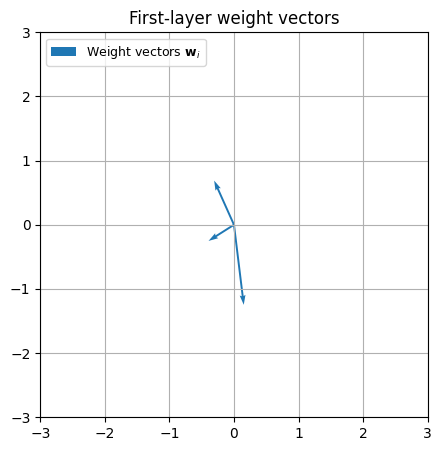

In [7]:
mlp = MLPClassifier(lr=5.0, h_dim=3)
loss_history, loss = [], np.inf
visualize_weights(mlp, gradients=False)

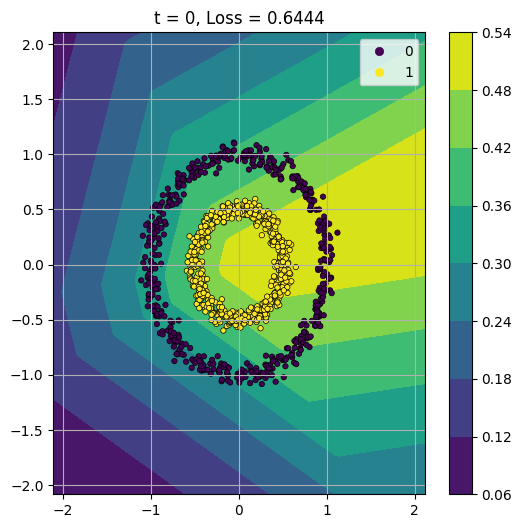

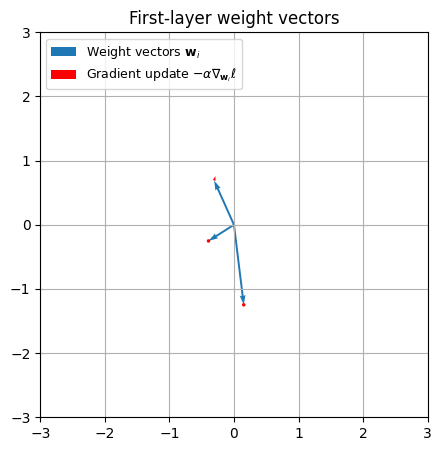

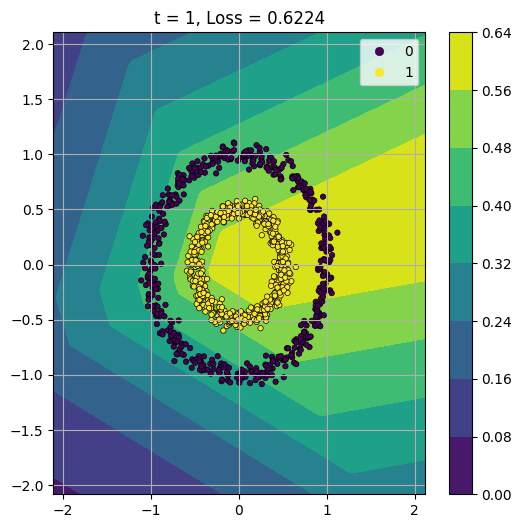

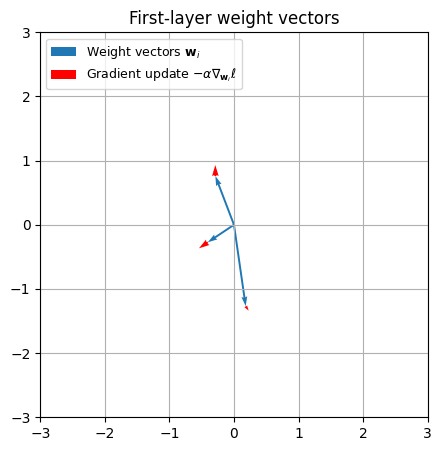

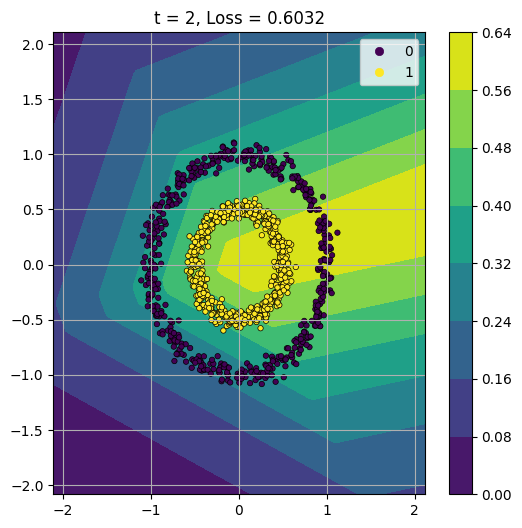

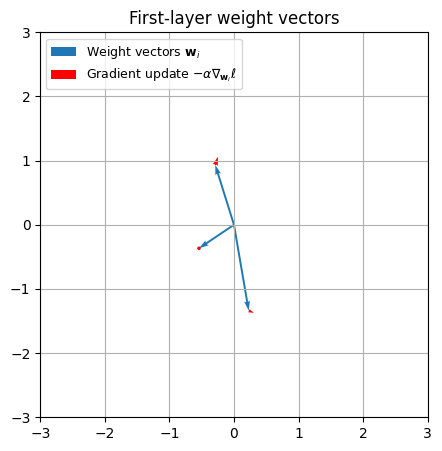

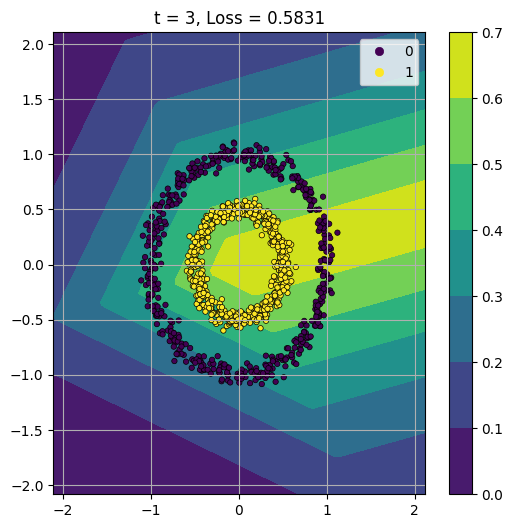

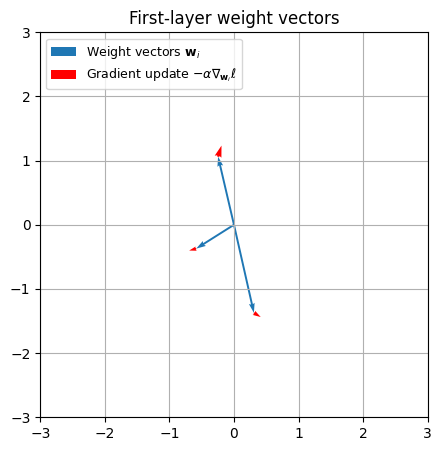

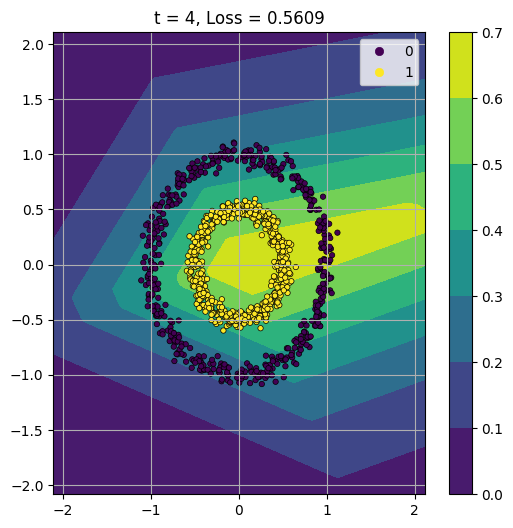

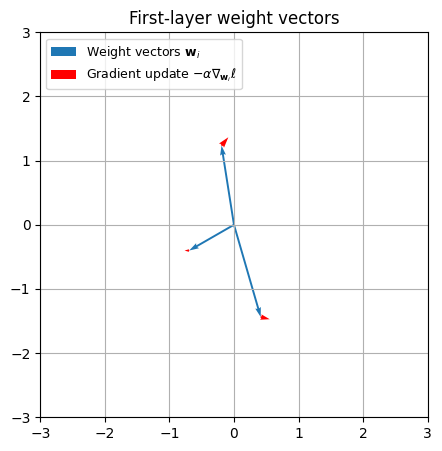

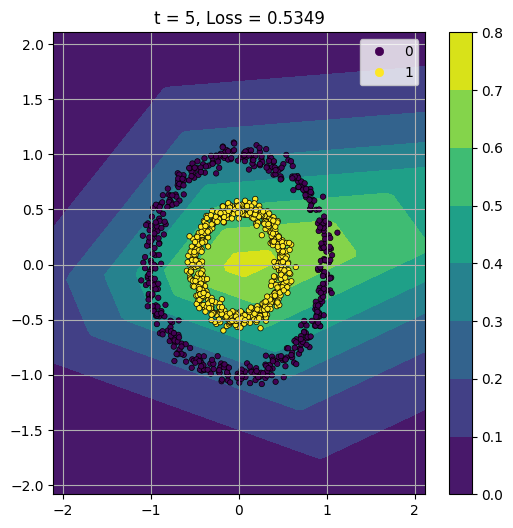

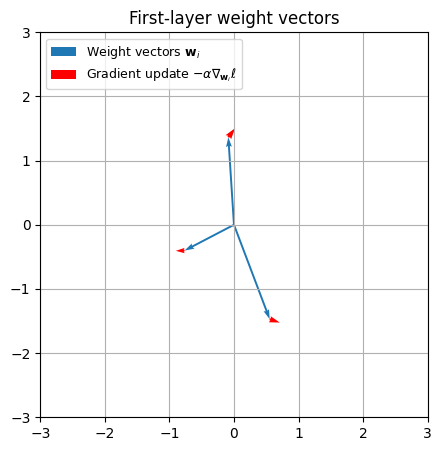

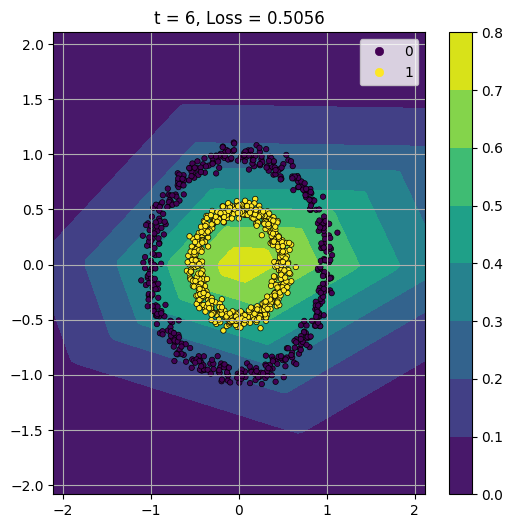

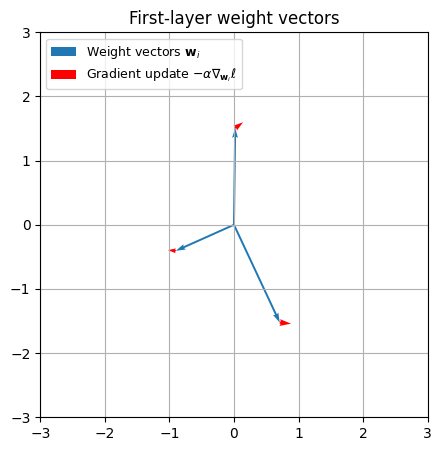

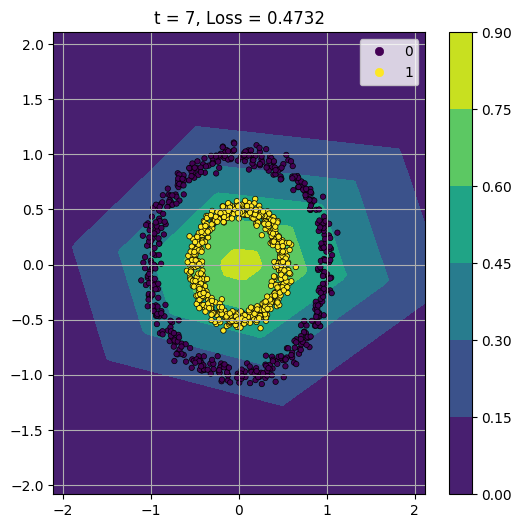

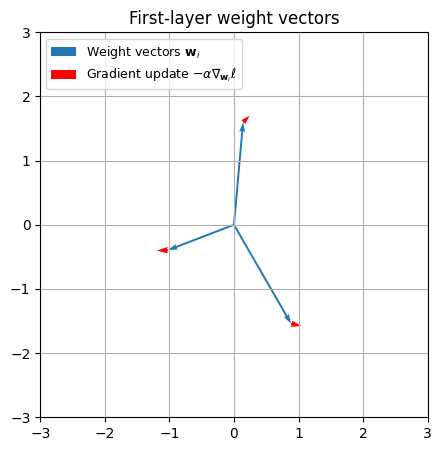

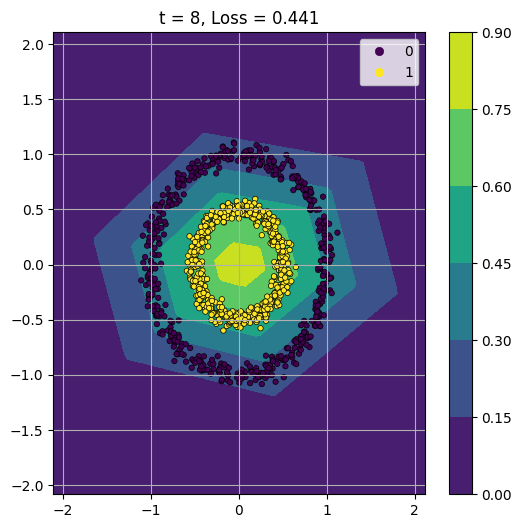

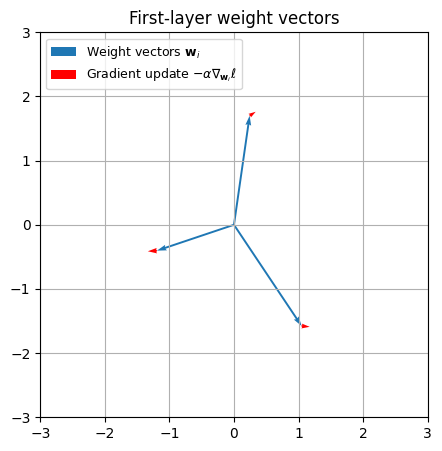

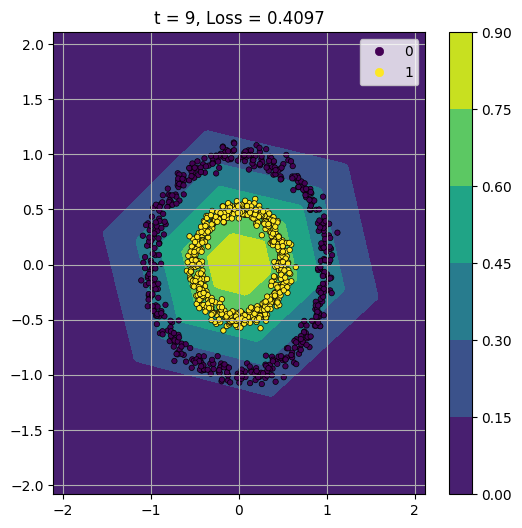

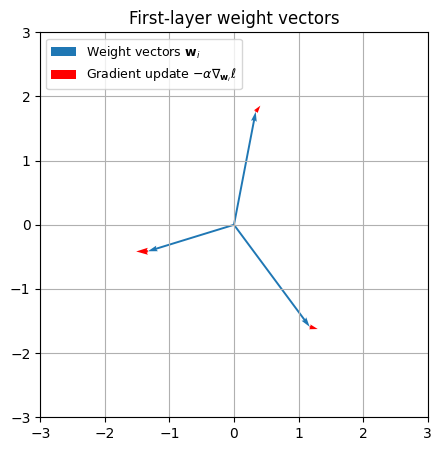

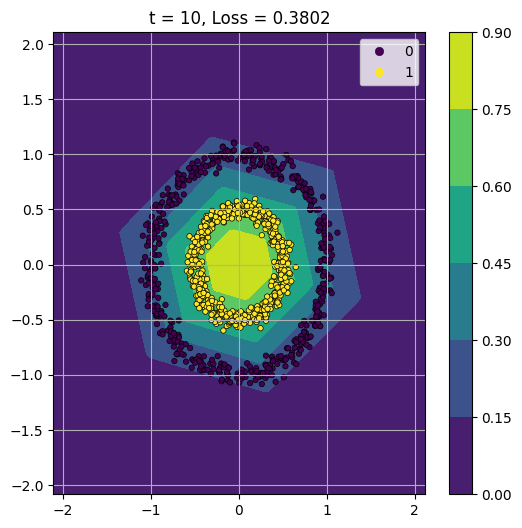

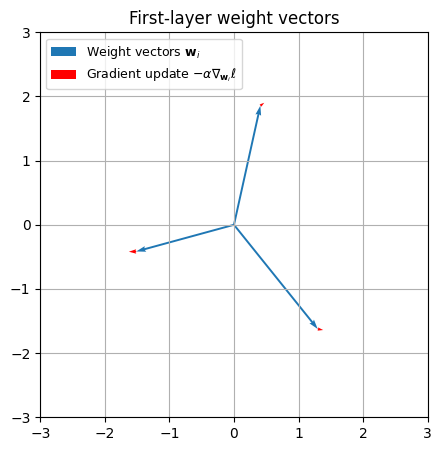

In [8]:
epochs = 10+1
N = X.shape[0]

for t in range(epochs):

    # Predict on data (forward pass)
    y_pred = mlp.forward(X)

    # Calculate and store loss
    loss = cross_entropy(y_pred, y)
    loss_history.append(loss)

    # Step 1 (BCE node): compute dL/dy_pred  (note the 1/N from the mean)
    grad_y_pred = (1 / N) * (-(np.divide(y, y_pred) - np.divide(1-y, 1-y_pred)))

    # Steps 2-5: backpropagate through sigmoid, linear, ReLU, linear
    mlp.backward(y_pred, grad_y_pred)

    # Visualize decision boundary with data overlay, and weight vectors
    if t % (epochs // 10) == 0:
        fig, ax = plt.subplots(figsize=(6, 6))
        display = plot_decision_boundary(mlp, X, ax=ax)
        plt.colorbar(display.ax_.collections[0], ax=ax)
        visualize_dataset(X, y, title=f"t = {t}, Loss = {round(loss, 4)}", ax=ax)
        visualize_weights(mlp)

    mlp.update()

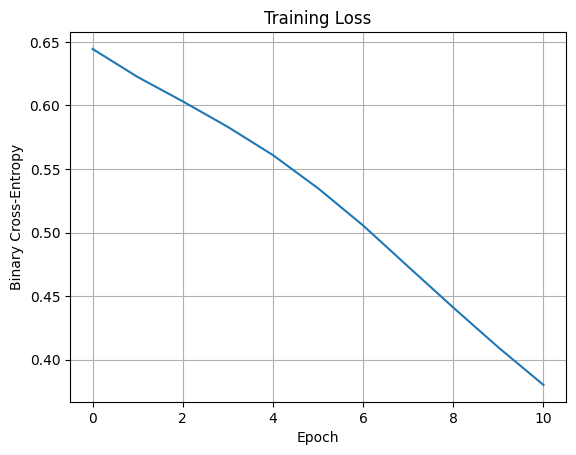

In [9]:
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.grid(True)
plt.show()

In [10]:
threshold = 0.5
acc = np.sum((y_pred > threshold) == y) / X.shape[0]
print(f"Accuracy = {acc}")

Accuracy = 0.998


### Gradient Checking

How do we know our `backward()` implementation is correct? We can verify it with **numerical gradient checking**. Recall from the lecture that the derivative is defined as:

$$\frac{df}{dx} \approx \frac{f(x+h) - f(x-h)}{2h}$$

We perturb each weight element by a small $h$, compute the loss twice, and compare the finite-difference gradient to our analytic gradient. If the relative error is small ($< 10^{-5}$), our backprop is correct.

In [11]:
def numerical_gradient(param, forward_fn, h=1e-5):
    """Compute numerical gradient of loss w.r.t. each element of param."""
    grad = np.zeros_like(param)
    it = np.nditer(param, flags=['multi_index'])
    while not it.finished:
        ix = it.multi_index
        old_val = param[ix]

        param[ix] = old_val + h
        loss_plus = forward_fn()
        param[ix] = old_val - h
        loss_minus = forward_fn()

        grad[ix] = (loss_plus - loss_minus) / (2 * h)
        param[ix] = old_val
        it.iternext()
    return grad

def check_gradient(name, param, analytic_grad, forward_fn):
    """Compare analytic gradient to numerical gradient and print relative error."""
    num_grad = numerical_gradient(param, forward_fn)
    diff = np.linalg.norm(analytic_grad - num_grad)
    norm_sum = np.linalg.norm(analytic_grad) + np.linalg.norm(num_grad)
    rel_error = diff / max(norm_sum, 1e-8)
    status = "OK" if rel_error < 1e-5 else "FAIL"
    print(f"  {name}: relative error = {rel_error:.2e}  [{status}]")

# Run a fresh forward + backward pass to get current analytic gradients
y_pred = mlp.forward(X)
N = X.shape[0]
grad_y_pred = (1 / N) * (-(np.divide(y, y_pred) - np.divide(1 - y, 1 - y_pred)))
mlp.backward(y_pred, grad_y_pred)

# Define a helper that computes the loss from the current weights
def compute_loss():
    preds = mlp.forward(X)
    return cross_entropy(preds, y)

print("Gradient check (analytic vs. numerical):")
check_gradient("w1", mlp.w1, mlp.grad_w1, compute_loss)
check_gradient("w2", mlp.w2, mlp.grad_w2, compute_loss)
check_gradient("b",  mlp.b,  mlp.grad_b,  compute_loss)

Gradient check (analytic vs. numerical):
  w1: relative error = 7.63e-11  [OK]
  w2: relative error = 5.75e-11  [OK]
  b: relative error = 1.69e-11  [OK]


### Geometric Interpretation of Learned Weights

Each column of $\mathbf{w}_1 \in \mathbb{R}^{2 \times 3}$ is a 2D vector that defines a half-plane (via the ReLU). Together, the three hidden neurons partition the input space into regions. For the concentric circles dataset, we'd expect the network to learn weight vectors that are roughly **evenly spaced** around the origin (~120 degrees apart), so that their intersection carves out a triangular approximation of the circular decision boundary.

Let's measure the angles between each pair of weight vectors to verify this:

In [13]:
idx = [0, 1, 2]
for i, j in itertools.combinations(idx, 2):
    wi, wj = mlp.w1[:, i], mlp.w1[:, j]
    print(f"Angle between weight {i} and {j} is {np.degrees(np.arccos((wi @ wj) / (np.linalg.norm(wi) * np.linalg.norm(wj)))):.2f} degrees.")

Angle between weight 0 and 1 is 118.31 degrees.
Angle between weight 0 and 2 is 126.05 degrees.
Angle between weight 1 and 2 is 115.64 degrees.


### Exercise: Implement the Backward Pass Yourself

Now it's your turn! The class below has the same `forward()` method, but `backward()` has blanks for you to fill in. Use the lecture slides (Steps 1-5) and the **upstream $\times$ local** pattern to derive each gradient.

**Hints:**
- The **shape rule** is your best friend: $\frac{\partial \ell}{\partial \mathbf{x}}$ always has the same shape as $\mathbf{x}$.
- For a linear layer $Y = XW$: $\frac{\partial \ell}{\partial W} = X^\top \frac{\partial \ell}{\partial Y}$ and $\frac{\partial \ell}{\partial X} = \frac{\partial \ell}{\partial Y} W^\top$ (multiply gate pattern).
- ReLU is a max gate: it **routes** the gradient where the input was positive and **kills** it elsewhere.

In [14]:
class MLPClassifierExercise():
    def __init__(self, lr=1e-2, in_dim=2, out_dim=1, h_dim=3):
        self.lr = lr
        self.w1 = np.random.randn(in_dim, h_dim) * np.sqrt(2 / in_dim)
        self.w2 = np.random.randn(h_dim, out_dim) * np.sqrt(2 / h_dim)
        self.b = np.zeros(out_dim) + 0.1

    def forward(self, x):
        self.x = x
        self.h = relu(self.x @ self.w1)
        self.z = self.h @ self.w2 + self.b
        y_pred = sigmoid(self.z)
        return y_pred

    def backward(self, y_pred, grad_y_pred):
        """
        TODO: Implement the backward pass. Fill in each gradient below.
        grad_y_pred is dL/dy_pred (already computed for you; this is Step 1).
        """
        # Step 2 (Sigmoid): dL/dz = dL/dy_pred * sigma'(z)
        # Hint: sigma'(z) = y_pred * (1 - y_pred)   (the "sigmoid trick")
        grad_z = y_pred*(1-y_pred)*grad_y_pred  # TODO

        # Step 3 (Linear layer z = h @ w2 + b):
        self.grad_w2 = self.h*grad_z # TODO: dL/dw2
        self.grad_b  = np.sum(grad_z)  # TODO: dL/db (remember b is broadcast across batch)
        self.grad_h  =   # TODO: dL/dh (to pass upstream)

        # Step 4 (ReLU): dL/d(Xw1) = dL/dh * 1[Xw1 > 0]
        grad_xw1 = None  # TODO

        # Step 5 (Linear layer Xw1):
        self.grad_w1 = None  # TODO: dL/dw1

    def update(self):
        self.w1 -= self.lr * self.grad_w1
        self.w2 -= self.lr * self.grad_w2
        self.b  -= self.lr * self.grad_b

In [ ]:
# Verify your exercise implementation with gradient checking
np.random.seed(231)
mlp_ex = MLPClassifierExercise(lr=5.0, h_dim=3)
y_pred_ex = mlp_ex.forward(X)
N = X.shape[0]
grad_y_pred_ex = (1 / N) * (-(np.divide(y, y_pred_ex) - np.divide(1 - y, 1 - y_pred_ex)))
mlp_ex.backward(y_pred_ex, grad_y_pred_ex)

def compute_loss_ex():
    preds = mlp_ex.forward(X)
    return cross_entropy(preds, y)

print("Gradient check for your implementation:")
check_gradient("w1", mlp_ex.w1, mlp_ex.grad_w1, compute_loss_ex)
check_gradient("w2", mlp_ex.w2, mlp_ex.grad_w2, compute_loss_ex)
check_gradient("b",  mlp_ex.b,  mlp_ex.grad_b,  compute_loss_ex)

Gradient check for your implementation:


TypeError: unsupported operand type(s) for -: 'NoneType' and 'float'